# MenuEye · EDA 노트북 (한국어 v2)

> **OCR 기반 한식 메뉴판 인식 + 다국어 LLM 푸드 가이드** — 기준: `PROJECT.md`
> 방한 외국인이 한식 메뉴를 못 읽는 문제를 **CV(PaddleOCR) + LLM**으로 해결.
> (유럽권 v1 `MenuEye_프로젝트`의 EDA 구조를 한국어 도메인으로 재작성)

## 구성
0. 환경 → 1. 데이터 개요(자체 촬영 6장) → 2. OCR 인식 현황(PP-OCRv5) →
3. 모델 개선 비교(PP-OCRv3 vs v5) → 4. 오류사례 분포 → 5. 핵심 인사이트

## 0. 환경 설정

In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from PIL import Image

# 한글 폰트
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if any(_f.lower() in f.name.lower() for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path("C:/Users/smhrd1/OneDrive/바탕 화면/menueye_v2")
IMG_DIR = ROOT / "data" / "menu_images" / "menu" / "한국"
OCR = ROOT / "data" / "ocr_results"
print("이미지 폴더:", IMG_DIR.exists(), "| OCR 요약:", (OCR / "ocr_summary.csv").exists(),
      "| 벤치마크:", (OCR / "benchmark.csv").exists())

이미지 폴더: True | OCR 요약: True | 벤치마크: True


## 1. 데이터 개요 — 자체 촬영 한식 메뉴판 6장

가장 중요한 도메인 데이터. 나라=한국(한식), 다양한 업종(해장국·순대국·횟집·중식·칼국수·백반)과
난이도(저해상도·초고밀도·다단·세로쓰기)를 의도적으로 포함해 **레이아웃 다양성**을 확보했다.

In [2]:
EXTS = (".jpg", ".jpeg", ".png", ".webp")
rows = []
for p in sorted(IMG_DIR.glob("*")):
    if p.suffix.lower() not in EXTS:
        continue
    try:
        with Image.open(p) as im:
            w, h = im.size
    except Exception:
        w = h = None
    rows.append({"파일": p.name, "가로": w, "세로": h,
                 "종횡비": round(w / h, 2) if w and h else None,
                 "용량KB": round(p.stat().st_size / 1024, 1)})
imgdf = pd.DataFrame(rows)
print(imgdf.to_string(index=False))
print("\n총", len(imgdf), "장 | 해상도 편차 큼(최소~최대 가로):",
      imgdf["가로"].min(), "~", imgdf["가로"].max())

   파일   가로  세로  종횡비   용량KB
1.jpg 1194 847 1.41  100.2
2.jpg  472 417 1.13   65.3
3.jpg  461 556 0.83   85.4
4.jpg  902 932 0.97  315.3
5.png 1280 912 1.40 1538.2
6.jpg  225 225 1.00    7.0

총 6 장 | 해상도 편차 큼(최소~최대 가로): 225 ~ 1280


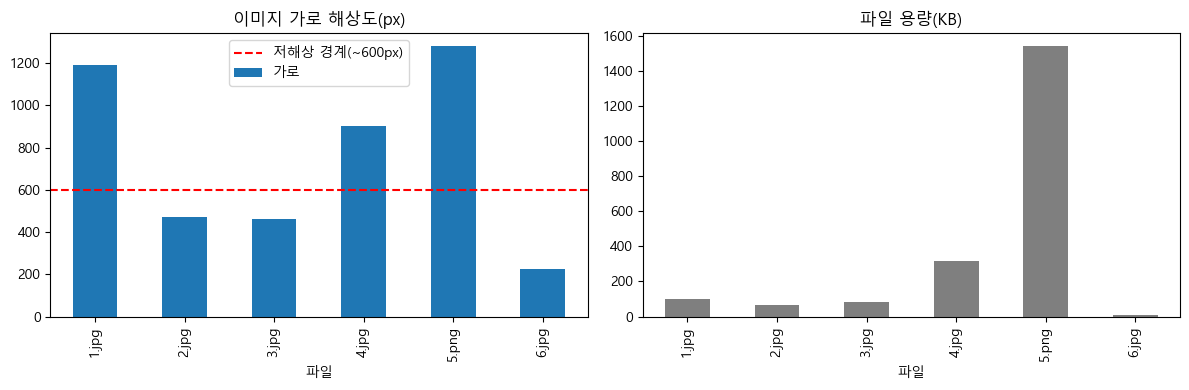

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
imgdf.plot.bar(x="파일", y="가로", ax=ax[0], legend=False, title="이미지 가로 해상도(px)", color="tab:blue")
ax[0].axhline(600, color="r", ls="--", label="저해상 경계(~600px)"); ax[0].legend()
imgdf.plot.bar(x="파일", y="용량KB", ax=ax[1], legend=False, title="파일 용량(KB)", color="tab:gray")
plt.tight_layout(); plt.show()
# 인사이트: 6.jpg가 유독 저해상(작은 px/용량) → 뒤 OCR에서 인식 난이도로 직결

## 2. OCR 인식 현황 — PP-OCRv5 (주력 모델)

`run_ocr.py`로 6장을 인식한 결과(`ocr_summary.csv`, `ocr_lines.csv`).
이미지별 **줄수 · 평균 신뢰도 · 저신뢰 비율 · 가격검출**을 본다.

In [4]:
summ = pd.read_csv(OCR / "ocr_summary.csv")
view = summ[["image", "n_lines", "mean_score", "low_conf_ratio", "n_price"]].copy()
print(view.to_string(index=False))
print("\n전체 평균 신뢰도:", round(summ["mean_score"].mean(), 3),
      "| 총 줄수:", int(summ["n_lines"].sum()))

        image  n_lines  mean_score  low_conf_ratio  n_price
menu/한국/1.jpg       73      0.9201          0.0274       19
menu/한국/2.jpg       68      0.9532          0.0000       28
menu/한국/3.jpg       56      0.9624          0.0179       21
menu/한국/4.jpg       47      0.9507          0.0426       16
menu/한국/5.png      133      0.8363          0.0677       27
menu/한국/6.jpg        4      0.9391          0.0000        4

전체 평균 신뢰도: 0.927 | 총 줄수: 381


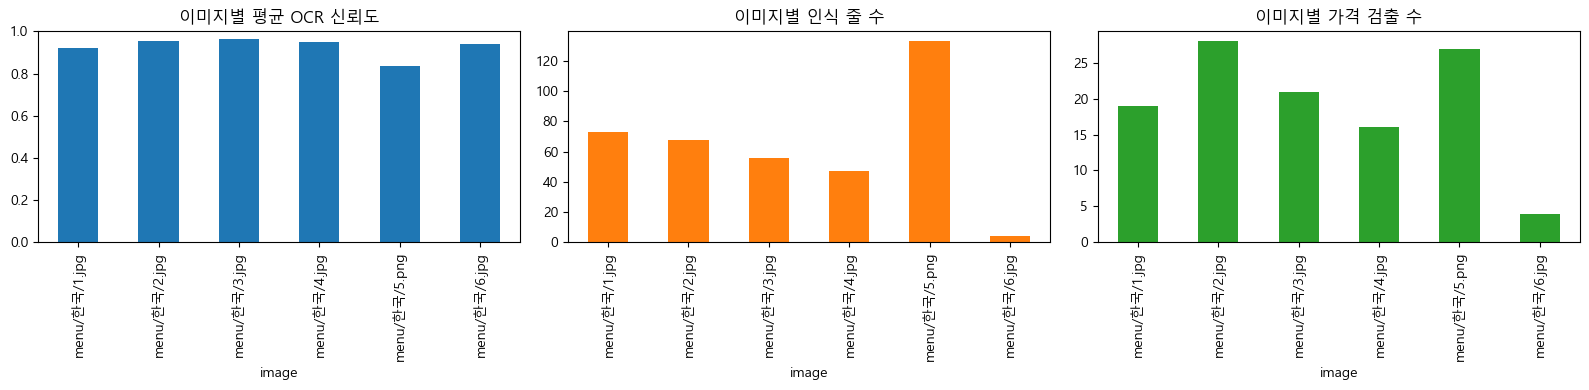

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
summ.plot.bar(x="image", y="mean_score", ax=ax[0], legend=False, title="이미지별 평균 OCR 신뢰도", color="tab:blue", ylim=(0, 1))
summ.plot.bar(x="image", y="n_lines", ax=ax[1], legend=False, title="이미지별 인식 줄 수", color="tab:orange")
summ.plot.bar(x="image", y="n_price", ax=ax[2], legend=False, title="이미지별 가격 검출 수", color="tab:green")
plt.tight_layout(); plt.show()

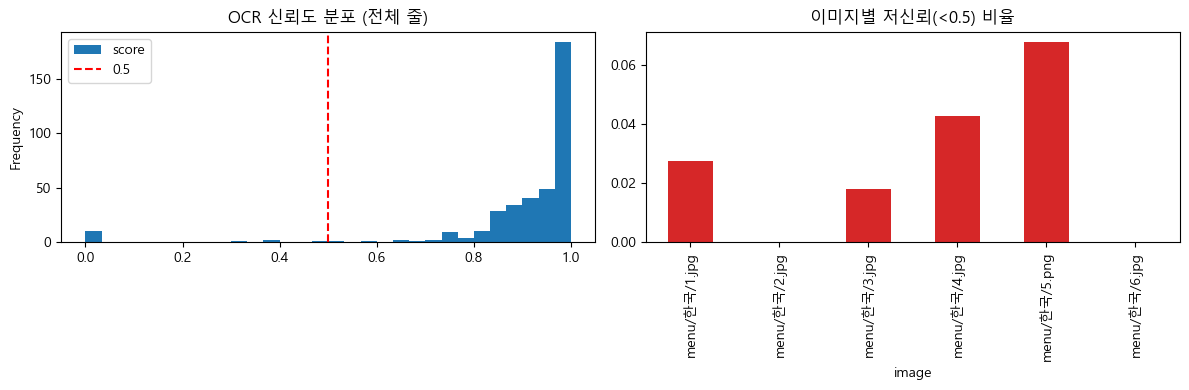

전체 저신뢰(<0.5) 비율: 3.7 %


In [6]:
# 줄 단위 신뢰도 분포 + 이미지별 저신뢰 비율
lines = pd.read_csv(OCR / "ocr_lines.csv")
sc = pd.to_numeric(lines["score"], errors="coerce").dropna()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sc.plot.hist(bins=30, ax=ax[0], title="OCR 신뢰도 분포 (전체 줄)", color="tab:blue")
ax[0].axvline(0.5, color="r", ls="--", label="0.5"); ax[0].legend()
(lines.assign(score=pd.to_numeric(lines["score"], errors="coerce"))
      .groupby("image")["score"].apply(lambda s: (s < 0.5).mean())
      .plot.bar(ax=ax[1], title="이미지별 저신뢰(<0.5) 비율", color="tab:red"))
plt.tight_layout(); plt.show()
print("전체 저신뢰(<0.5) 비율:", round((sc < 0.5).mean() * 100, 1), "%")
# 인사이트: 전체 신뢰도는 높지만(v5), 5.png(초고밀도 중식)이 최저 → 밀도가 병목

## 3. 모델 개선 비교 — PP-OCRv3(베이스라인) vs PP-OCRv5(개선)

같은 후처리(좌표 병합)를 두 모델에 동일 적용해 **모델 효과만 격리**한 '메뉴명 복원율'.
(원어민 정답 `truth_<N>.txt` 대비, `benchmark_ocr.py` 산출)

In [7]:
import re
bm = pd.read_csv(OCR / "benchmark.csv")
def frac(s):
    m = re.match(r"\s*(\d+)/(\d+)", str(s)); return (int(m.group(1)), int(m.group(2))) if m else (0, 1)
bm["v3%"] = bm["PP-OCRv3"].map(lambda s: round(frac(s)[0] / frac(s)[1] * 100))
bm["v5%"] = bm["PP-OCRv5"].map(lambda s: round(frac(s)[0] / frac(s)[1] * 100))
print(bm[["image", "truth", "PP-OCRv3", "PP-OCRv5"]].to_string(index=False))
n3 = sum(frac(s)[0] for s in bm["PP-OCRv3"]); d3 = sum(frac(s)[1] for s in bm["PP-OCRv3"])
n5 = sum(frac(s)[0] for s in bm["PP-OCRv5"]); d5 = sum(frac(s)[1] for s in bm["PP-OCRv5"])
print(f"\n전체 복원율: v3 {n3}/{d3} ({n3/d3:.0%}) → v5 {n5}/{d5} ({n5/d5:.0%})")

image  truth     PP-OCRv3     PP-OCRv5
1.jpg     14  13/14 (93%)  13/14 (93%)
2.jpg     24  19/24 (79%)  23/24 (96%)
3.jpg     12 12/12 (100%) 12/12 (100%)
4.jpg      8    7/8 (88%)    7/8 (88%)
5.png     22   6/22 (27%)  15/22 (68%)
6.jpg      4    2/4 (50%)   4/4 (100%)

전체 복원율: v3 59/84 (70%) → v5 74/84 (88%)


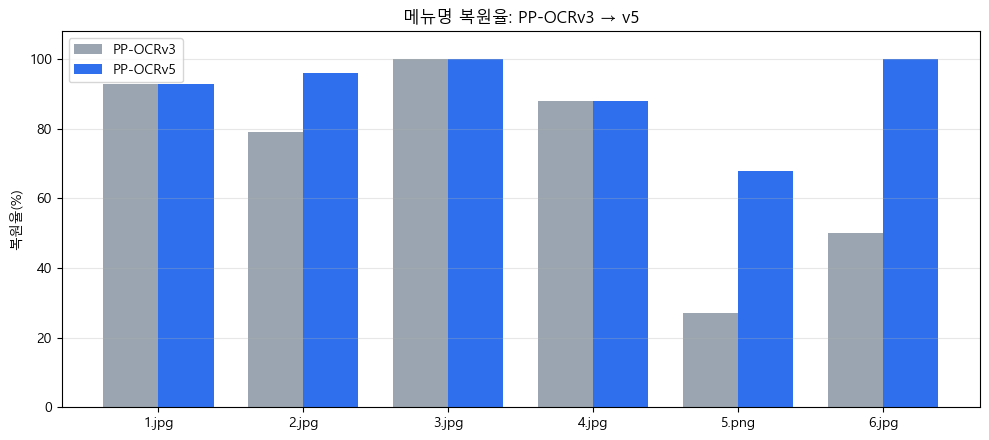

In [8]:
x = np.arange(len(bm)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, bm["v3%"], w, label="PP-OCRv3", color="#9aa5b1")
ax.bar(x + w/2, bm["v5%"], w, label="PP-OCRv5", color="#2f6fed")
ax.set_xticks(x); ax.set_xticklabels(bm["image"]); ax.set_ylabel("복원율(%)"); ax.set_ylim(0, 108)
ax.set_title("메뉴명 복원율: PP-OCRv3 → v5"); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
# 인사이트: 저해상 6.jpg(50→100), 초고밀도 5.png(27→68)에서 v5가 결정적

## 4. 오류사례 분포 (요약)

`오류사례분석.md`의 유형별 정리를 상태(해결/부분/미해결)로 집계.
남은 실패는 대부분 **구조(밀도·레이아웃)** 문제이지 단순 인식 문제가 아니다.

        유형  레이어  상태
      저해상도  ①인식  해결
  초고밀도 소자체  ①인식 미해결
   오인식(치환)  ①인식  부분
      글자붙음 ②후처리  해결
     大中 분리 ②후처리  해결
 세로/다단 과병합 ②후처리  해결
세로 섹션헤더 오염 ②후처리  부분
    간판 오생성 ③LLM  해결
 환각(재료/풍미) ③LLM  해결
 곁들임/사리 누락 ③LLM  해결


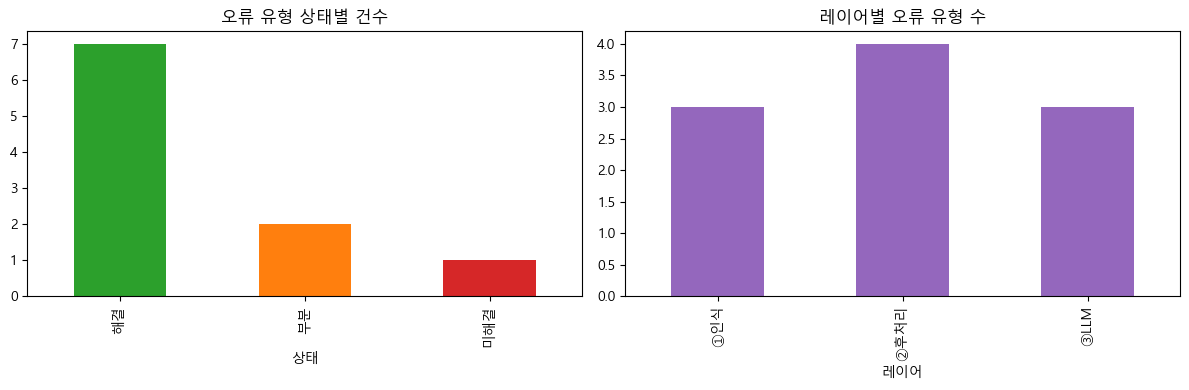

In [9]:
err = pd.DataFrame([
    ("저해상도",       "①인식",   "해결"),
    ("초고밀도 소자체", "①인식",   "미해결"),
    ("오인식(치환)",   "①인식",   "부분"),
    ("글자붙음",       "②후처리", "해결"),
    ("大中 분리",      "②후처리", "해결"),
    ("세로/다단 과병합", "②후처리", "해결"),
    ("세로 섹션헤더 오염","②후처리", "부분"),
    ("간판 오생성",    "③LLM",    "해결"),
    ("환각(재료/풍미)", "③LLM",    "해결"),
    ("곁들임/사리 누락", "③LLM",    "해결"),
], columns=["유형", "레이어", "상태"])
print(err.to_string(index=False))
order = ["해결", "부분", "미해결"]; color = {"해결": "tab:green", "부분": "tab:orange", "미해결": "tab:red"}
cnt = err["상태"].value_counts().reindex(order).fillna(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cnt.plot.bar(ax=ax[0], color=[color[s] for s in order], title="오류 유형 상태별 건수")
err["레이어"].value_counts().sort_index().plot.bar(ax=ax[1], color="tab:purple", title="레이어별 오류 유형 수")
plt.tight_layout(); plt.show()

## 5. 핵심 인사이트 (EDA 결론)

1. **데이터 다양성 확보** — 6장이 업종·난이도(저해상·초고밀도·다단·세로쓰기)를 폭넓게 커버 → 오류사례가 풍부.
2. **v5 인식 신뢰도는 높음(평균 0.91, 저신뢰 3.7%)** — 단, 신뢰도가 높아도 **밀도/레이아웃 때문에 '메뉴 복원'은 별개**(5.png).
3. **개선의 지렛대 = 모델 선택(v3→v5)** — 복원율 70%→88%. 특히 저해상·초고밀도에서 결정적. (파인튜닝 아님 → `WORKLOG.md` 6-2)
4. **남은 병목은 '구조'** — 초고밀도 소자체, 세로 섹션헤더 vs 그리드 구분. → 향후 레이아웃 분석/멀티모달 비전 모델.
5. **정직한 측정** — 채점기(`compare_menu.py`) 한글 버그를 먼저 잡고(NFC+가-힣) 원본 기준으로 측정.